This example shows how UNKNOWN data distribution plays a role in learning.

1. Let us assume one is transmitting bits in a noise channel. The channel would flip the bit with a probability $1-\beta$. I.e. $\beta$ is the reliability, and if $\beta=0.95$ and the sender's bit is "1", then the receiver get  "1" in 95 out of 100 times on average, and "0" in the rest.

To have a more reliable communication, the sender decided to repeat every bit three times.

See example below. It shows the encoding (repeat 3 times) of a piece of message of 32 bits.

In [1]:
import numpy as np
rng = np.random.RandomState(42)
def noise_channel(bits_in, beta):
    bits_out = np.zeros_like(bits_in)
    for i in range(len(bits_out)):
        bits_out[i] = bits_in[i] if rng.rand() < beta else (1 - bits_in[i])
    return bits_out

sender_msg = rng.randint(2, size=(32,))
beta = 0.95
for b in sender_msg:
    sender_bits_i = np.array([b, ]*3, dtype=np.uint8)
    print(noise_channel(sender_bits_i, beta), b)


[0 0 0] 0
[1 1 1] 1
[0 0 0] 0
[0 0 0] 0
[0 0 0] 0
[1 1 1] 1
[1 0 0] 0
[0 0 0] 0
[0 0 0] 0
[1 1 1] 1
[0 0 0] 0
[0 1 0] 0
[0 0 0] 0
[0 0 0] 0
[1 1 1] 1
[0 0 0] 0
[1 1 1] 1
[1 1 0] 1
[1 1 1] 1
[0 0 0] 0
[1 1 1] 1
[0 0 0] 0
[1 1 1] 1
[1 1 1] 1
[1 1 1] 1
[1 1 1] 1
[1 1 1] 1
[1 1 1] 1
[1 1 1] 1
[1 1 1] 1
[0 0 0] 0
[0 0 0] 0


In [9]:
if True: # This is a one-time data preparation code segment. No longer used.
    from PIL import Image
    imfile = "Data/duckhw.png"
    image = Image.open(imfile).convert('RGB')
    image = image.resize((64, 64))
    image = (np.array(image)[:, :, 0] > 128).astype(np.float32)
    py, px = np.nonzero(1-image)
    bits = image.astype(np.uint8)
    with open('tmpout.txt', 'w') as f:
        for l in bits:
            for b in l:
                f.write(f"{b},")
            # f.write('\n')

In [11]:
# np.loadtxt()
bits = np.loadtxt("tmpout.txt", delimiter=',')


array([1., 1., 1., ..., 1., 1., 1.])

In [12]:
received_bits = []
beta = 0.8
for b in bits:
    sender_bits_i = np.array([b, ]*3, dtype=np.uint8)
    received_bits.append(noise_channel(sender_bits_i, beta))

Please adjust $\beta$ to check the performance of two different decoding hypotheses.

In [22]:
decoded_msg_1 = []
decoded_msg_2 = []
decoded_msg_3 = []

def decoder_1(bs):
    # voting
    n0 = (bs==0).sum()
    n1 = (bs==1).sum()
    if n0 > n1: return 0
    else: return 1

def decoder_2(bs):
    # Any
    n0 = (bs==0).sum()
    if n0 == 3: return 0
    else: return 1

def decoder_3(bs):
    # All
    n0 = (bs==0).sum()
    if n0 == 0: return 0
    else: return 1


for bb in received_bits:
    decoded_msg_1.append(decoder_1(bb))
    decoded_msg_2.append(decoder_2(bb))
    decoded_msg_3.append(decoder_3(bb))

channel_msg = noise_channel(bits, beta)
decoded_msg_1 = np.array(decoded_msg_1)
decoded_msg_2 = np.array(decoded_msg_2)
decoded_msg_3 = np.array(decoded_msg_3)

print("Total bits:", len(bits))
print("Channel erros:", (channel_msg!=bits).sum())
print("Errors 1:", (decoded_msg_1!=bits).sum())
print("Errors 2:", (decoded_msg_2!=bits).sum())
print("Errors 3:", (decoded_msg_3!=bits).sum())


Total bits: 4096
Channel erros: 816
Errors 1: 428
Errors 2: 247
Errors 3: 2331


Text(0.5, 1.0, '3-repeat all-1 data prior')

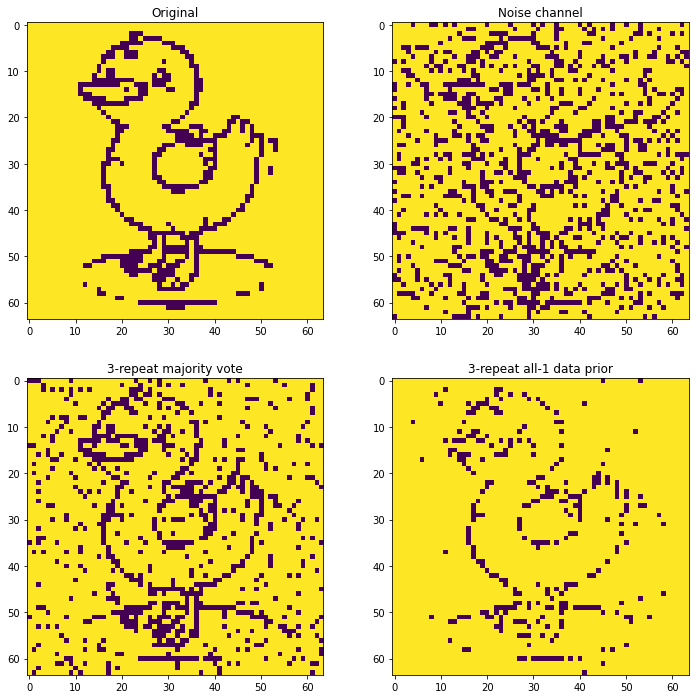

In [4]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(12, 12))
axs[0, 0].imshow(bits.reshape(64, 64))
axs[0, 0].set_title("Original")
axs[0, 1].imshow(channel_msg.reshape(64, 64))
axs[0, 1].set_title("Noise channel")
axs[1, 0].imshow(decoded_msg_1.reshape(64, 64))
axs[1, 0].set_title("3-repeat majority vote")
axs[1, 1].imshow(decoded_msg_2.reshape(64, 64))
axs[1, 1].set_title("3-repeat all-1 data prior")

